[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/takechanman1228/marketing-science-in-python/blob/main/notebooks/part4-customer-analytics/sec4.1_traditional_segmentation.ipynb)

# Customer Segmentation — Traditional Methods

This notebook accompanies **§4.1** of *Marketing Science in Python*.
It walks through the three layers the chapter calls out — decile, RFM, and
K-Means — and ends with a CRM-ready export.

For embedding-based segmentation (BERTopic + LLM naming), see the companion
script `sec4.1_semantic_segmentation.py`.

**Learning objectives**

1. Use decile analysis to reveal revenue concentration.
2. Compute RFM (Recency, Frequency, Monetary) scores with **M-aware** segment labels.
3. Engineer 8–10 behavioral features (frequency, spend, recency, basket size,
   category breadth, discount sensitivity, …) and scale them.
4. Choose K with the elbow method **and** a business-judgment sanity check
   (final K from the 3–8 practical range).
5. Profile segments with a heatmap and demographic cross-tabs.
6. Test temporal stability with a decile migration matrix.
7. Export CRM-ready segment assignments.

**Dataset**: Dunnhumby "The Complete Journey" — 2.6 M transaction rows joined
with product master and household demographics.

In [1]:
# Colab: install the Kaggle download helper used as a data-loading fallback.
%pip install -q kagglehub

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ── All tuneable parameters in one place ─────────────────────────────────────
CONFIG = {
    "data_path": "../../data/raw/Dunnhumby_kaggle/",
    "kaggle_dataset": "frtgnn/dunnhumby-the-complete-journey",
    "max_week": 102,           # last week in the dataset
    "rfm_quintiles": 5,        # number of quintile bins for RFM
    "k_range": range(2, 21),   # K values to search for the elbow
    "final_k": 5,              # chosen from the 3–8 practical range (clears the 10% floor after log-transform)
    "skew_threshold": 1.0,     # log1p any behavioral feature with skew above this
    "min_cluster_share": 0.10, # rough size guide for actionable segments (not a hard rule)
    "random_state": 42,
}

ACCENT_BLUE = "#2171b5"
ACCENT_ORANGE = "#e6550d"
ACCENT_GREEN = "#31a354"
ACCENT_PURPLE = "#756bb1"
ACCENT_GREY = "#969696"

pd.set_option("display.float_format", "{:.2f}".format)

try:
    display
except NameError:
    display = print
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.facecolor": "white",
})

In [3]:
# Colab bootstrap: make the `msbook` helper package importable.
# Local / conda users already have it via `pip install -e .` from the repo root,
# so this is a no-op for them. On Colab it clones the book repo and installs
# msbook in editable mode. (A plain `pip install git+...` is not enough: msbook
# resolves paths by walking up to the repo's _quarto.yml, so it needs the repo
# tree present, which the clone provides.)
import sys
try:
    import msbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess
    _REPO = "https://github.com/takechanman1228/marketing-science-in-python.git"
    subprocess.run(["git", "clone", "-q", _REPO], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    "marketing-science-in-python"], check=True)
    import msbook  # noqa: F401
from msbook.paths import chapter_images, chapter_artifacts

_FIG_DIR = chapter_images(part="4", chapter="sec4.1")   # canonical, committed under images/
_LOCAL_FIG_DIR = Path("output") / "figures"             # local cache beside the notebook (gitignored)
_LOCAL_FIG_DIR.mkdir(parents=True, exist_ok=True)
_TABLES  = chapter_artifacts(part="4", chapter="sec4.1-segmentation") / "tables"
_TABLES.mkdir(parents=True, exist_ok=True)


def savefig(fig, name, **kw):
    """Dual-save: write each figure to the canonical images/ dir, then copy it
    byte-for-byte into a local output/figures cache. test_segmentation.py compares
    the two so a stale or uncommitted canonical figure is caught early."""
    kw.setdefault("dpi", 150)
    kw.setdefault("bbox_inches", "tight")
    fig.savefig(_FIG_DIR / name, **kw)
    shutil.copyfile(_FIG_DIR / name, _LOCAL_FIG_DIR / name)

_step = 0

def step(title):
    global _step
    _step += 1
    print(f"\n{'='*60}")
    print(f"  Step {_step}: {title}")
    print(f"{'='*60}\n")

## 1. Data Loading & Feature Engineering

The Dunnhumby dataset contains:

| File | Contents | Key Columns |
|------|----------|-------------|
| `transaction_data.csv` | 2.6 M transaction rows | `household_key`, `BASKET_ID`, `SALES_VALUE`, `RETAIL_DISC`, `COUPON_DISC`, `WEEK_NO` |
| `product.csv` | Product master | `PRODUCT_ID`, `DEPARTMENT`, `COMMODITY_DESC` |
| `hh_demographic.csv` | Household demographics (801 HHs) | `AGE_DESC`, `INCOME_DESC`, `HOUSEHOLD_SIZE_DESC`, etc. |

We aggregate transactions to one row per household, computing **nine
behavioral features** that go into clustering. The chapter calls for 6–10
such variables that capture more than spend, frequency, and recency.

| Feature | Definition |
|---|---|
| `total_revenue` | Σ `SALES_VALUE` per household |
| `frequency` | distinct baskets (`BASKET_ID`) |
| `recency_weeks` | `max_week - last_purchase_week` |
| `avg_order_value` | `total_revenue / frequency` |
| `basket_size` | mean items per basket |
| `active_weeks` | distinct `WEEK_NO` with a purchase |
| `discount_share` | discount $ / gross $ (sensitivity to promotions) |
| `department_breadth` | distinct departments shopped |
| `top_department_share` | revenue share of the top department (concentration) |

In [4]:
step("Load raw data")

data_dir = Path(CONFIG["data_path"])
if not (data_dir / "transaction_data.csv").exists():
    # Fallback: download via kagglehub (Colab / first-time readers)
    try:
        import kagglehub
        data_dir = Path(kagglehub.dataset_download(CONFIG["kaggle_dataset"]))
        print(f"Downloaded Dunnhumby to {data_dir}")
    except Exception as e:
        raise FileNotFoundError(
            f"Dunnhumby data not found at {data_dir}. Download from Kaggle: "
            f"https://www.kaggle.com/datasets/{CONFIG['kaggle_dataset']}\n"
            f"Error: {e}"
        )

txn = pd.read_csv(data_dir / "transaction_data.csv")
demographics = pd.read_csv(data_dir / "hh_demographic.csv")
try:
    product = pd.read_csv(data_dir / "product.csv")
except FileNotFoundError as e:
    raise FileNotFoundError(
        f"product.csv not found in {data_dir}. The 9-feature build needs the "
        "product master for department_breadth and top_department_share. "
        "Download Dunnhumby 'The Complete Journey' (Kaggle) and place "
        "product.csv next to transaction_data.csv."
    ) from e

print(f"Transactions:  {len(txn):>10,} rows  |  {txn['household_key'].nunique():,} households")
print(f"Demographics:  {len(demographics):>10,} rows  |  {demographics['household_key'].nunique()} households")
print(f"Products:      {len(product):>10,} rows  |  {product['DEPARTMENT'].nunique()} departments")
print(f"Week range:    {txn['WEEK_NO'].min()}–{txn['WEEK_NO'].max()}")


  Step 1: Load raw data



Transactions:   2,595,732 rows  |  2,500 households
Demographics:         801 rows  |  801 households
Products:          92,353 rows  |  44 departments
Week range:    1–102


In [5]:
step("Feature engineering — one row per household, nine behavioral features")

max_week = CONFIG["max_week"]

# Dunnhumby convention: RETAIL_DISC and COUPON_DISC are stored as
# *negative* values (the discount amount). gross = paid - disc.
txn["DISCOUNT"] = -(txn["RETAIL_DISC"].fillna(0) + txn["COUPON_DISC"].fillna(0))
txn["DISCOUNT"] = txn["DISCOUNT"].clip(lower=0)
txn["GROSS"] = txn["SALES_VALUE"] + txn["DISCOUNT"]

# Join department onto every transaction row
txn = txn.merge(product[["PRODUCT_ID", "DEPARTMENT"]], on="PRODUCT_ID", how="left")

# Core RFM-style aggregates
agg = (
    txn.groupby("household_key")
    .agg(
        total_revenue=("SALES_VALUE", "sum"),
        gross_spend=("GROSS", "sum"),
        discount_spend=("DISCOUNT", "sum"),
        frequency=("BASKET_ID", "nunique"),
        last_week=("WEEK_NO", "max"),
        active_weeks=("WEEK_NO", "nunique"),
        total_items=("QUANTITY", "sum"),
        department_breadth=("DEPARTMENT", "nunique"),
    )
    .reset_index()
)

# Top-department concentration (max share of any single department's revenue)
dept_rev = (
    txn.groupby(["household_key", "DEPARTMENT"])["SALES_VALUE"].sum().reset_index()
)
top_dept = (
    dept_rev.groupby("household_key")["SALES_VALUE"].max().reset_index()
    .rename(columns={"SALES_VALUE": "top_dept_rev"})
)
agg = agg.merge(top_dept, on="household_key", how="left")
agg["top_department_share"] = (agg["top_dept_rev"] / agg["total_revenue"]).clip(0, 1)

# Derived per-household features
agg["recency_weeks"] = max_week - agg["last_week"]
agg["avg_order_value"] = agg["total_revenue"] / agg["frequency"]
agg["basket_size"] = agg["total_items"] / agg["frequency"]
agg["discount_share"] = (
    agg["discount_spend"] / agg["gross_spend"].replace(0, np.nan)
).fillna(0).clip(0, 1)

customers = agg[[
    "household_key",
    "total_revenue", "frequency", "recency_weeks",
    "avg_order_value", "basket_size", "active_weeks",
    "discount_share", "department_breadth", "top_department_share",
]].copy()

BASE_COLS = [
    "total_revenue", "frequency", "recency_weeks",
    "avg_order_value", "basket_size", "active_weeks",
    "discount_share", "department_breadth", "top_department_share",
]

print(f"Customers: {len(customers):,}")
print(f"\nFeature summary ({len(BASE_COLS)} behavioral variables):")
display(customers[BASE_COLS].describe().round(3))

customers.to_csv(_TABLES / "trad_customer_features.csv", index=False)


  Step 2: Feature engineering — one row per household, nine behavioral features



Customers: 2,500

Feature summary (9 behavioral variables):


,total_revenue,frequency,recency_weeks,avg_order_value,basket_size,active_weeks,discount_share,department_breadth,top_department_share
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,3222.99,110.59,3.42,31.62,726.70,49.59,0.16,12.97,0.53
std,3349.03,115.67,8.96,19.05,1239.62,25.54,0.05,3.85,0.11
min,8.17,1.00,0.00,2.39,1.59,1.00,0.01,1.00,0.24
25%,970.74,39.00,0.00,18.33,13.51,28.00,0.12,10.00,0.45
50%,2157.75,79.00,1.00,27.42,137.47,50.00,0.15,13.00,0.53
75%,4413.32,142.25,3.00,40.55,965.78,71.00,0.18,16.00,0.59
max,38319.79,1300.00,94.00,165.83,16322.50,102.00,0.44,24.00,1.00


## 2. Decile Analysis

Divide customers into ten equal groups ranked by revenue. The top decile
routinely captures 40–60 percent of revenue; the bottom four are rarely
worth a paid touch. Mapping deciles to **action tiers** is the simplest
possible segmentation that still drives spend.

In [6]:
step("Decile analysis")

customers = customers.sort_values("total_revenue", ascending=False)
customers["decile"] = pd.qcut(
    customers["total_revenue"].rank(method="first", ascending=False),
    q=10,
    labels=[f"D{i}" for i in range(1, 11)],
)

decile_profile = (
    customers.groupby("decile", observed=True)
    .agg(
        n_customers=("household_key", "count"),
        total_revenue=("total_revenue", "sum"),
        avg_frequency=("frequency", "mean"),
        avg_order_value=("avg_order_value", "mean"),
    )
)
decile_profile["revenue_share"] = (
    decile_profile["total_revenue"] / decile_profile["total_revenue"].sum()
)
decile_profile["cumulative_share"] = decile_profile["revenue_share"].cumsum()

# Action tiers
action_map = {
    "D1":  "VIP: retain and reward",
    "D2":  "Grow basket or category",
    "D3":  "Grow basket or category",
    "D4":  "Grow basket or category",
    "D5":  "Low-cost nurture",
    "D6":  "Low-cost nurture",
    "D7":  "Low-cost nurture",
    "D8":  "Suppress expensive offers",
    "D9":  "Suppress expensive offers",
    "D10": "Suppress expensive offers",
}
decile_profile["action_tier"] = decile_profile.index.map(action_map)
customers["decile_action_tier"] = customers["decile"].map(action_map)

decile_profile.to_csv(_TABLES / "trad_decile_profile.csv", index=True)
display(decile_profile)


  Step 3: Decile analysis



,n_customers,total_revenue,avg_frequency,avg_order_value,revenue_share,cumulative_share,action_tier
decile,,,,,,,
D1,250,2763010.95,293.99,48.04,0.34,0.34,VIP: retain and reward
D2,250,1511177.30,192.46,38.78,0.19,0.53,Grow basket or category
D3,250,1102854.92,147.23,38.15,0.14,0.67,Grow basket or category
D4,250,804333.49,126.53,32.70,0.10,0.77,Grow basket or category
D5,250,614383.37,99.95,31.42,0.08,0.84,Low-cost nurture
D6,250,474330.04,84.76,29.45,0.06,0.90,Low-cost nurture
D7,250,346887.08,65.64,28.12,0.04,0.95,Low-cost nurture
D8,250,241269.01,45.08,27.13,0.03,0.98,Suppress expensive offers
D9,250,142852.27,34.02,23.18,0.02,0.99,Suppress expensive offers



  Step 4: Decile visualizations



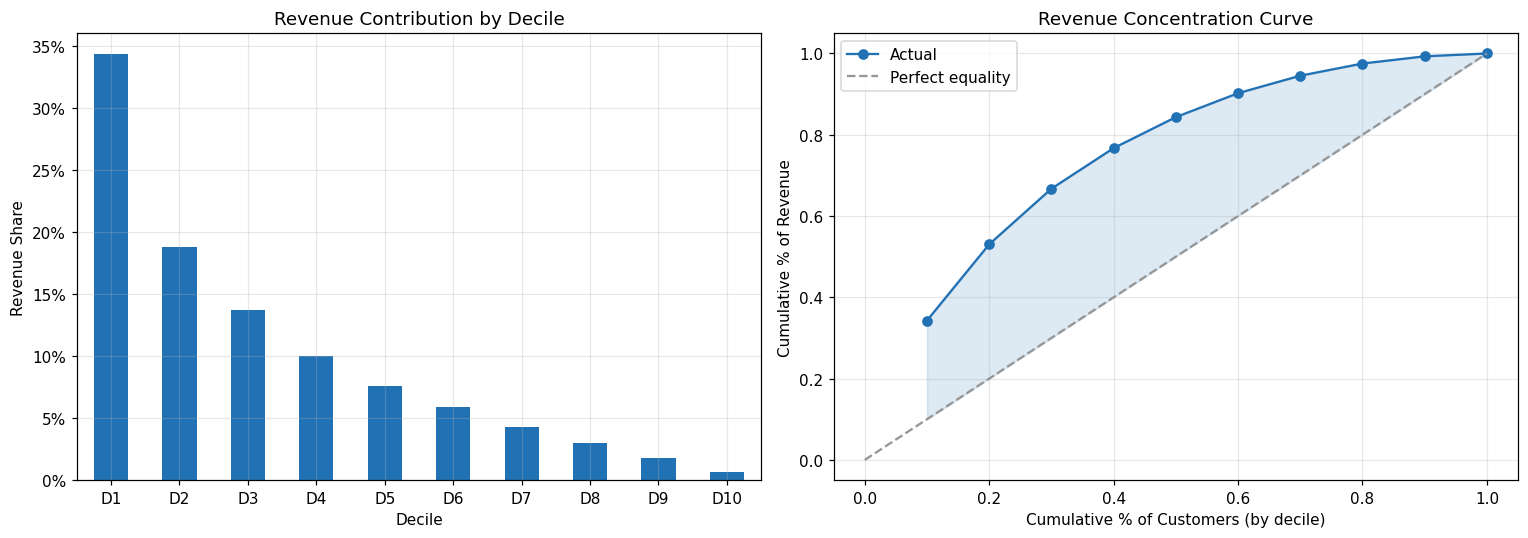

D1 (top 10%) contributes 34.3% of total revenue.


In [7]:
step("Decile visualizations")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
decile_profile["revenue_share"].plot(kind="bar", ax=ax, color=ACCENT_BLUE)
ax.set_ylabel("Revenue Share")
ax.set_xlabel("Decile")
ax.set_title("Revenue Contribution by Decile")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.tick_params(axis="x", rotation=0)

ax = axes[1]
x = np.arange(1, 11) / 10
ax.plot(x, decile_profile["cumulative_share"].values, "o-",
        color=ACCENT_BLUE, label="Actual")
ax.plot([0, 1], [0, 1], "--", color=ACCENT_GREY, label="Perfect equality")
ax.fill_between(x, decile_profile["cumulative_share"].values, x,
                alpha=0.15, color=ACCENT_BLUE)
ax.set_xlabel("Cumulative % of Customers (by decile)")
ax.set_ylabel("Cumulative % of Revenue")
ax.set_title("Revenue Concentration Curve")
ax.legend()

fig.tight_layout()
savefig(fig, "decile_distribution.png")
plt.show()

d1_share = decile_profile.loc["D1", "revenue_share"]
print(f"D1 (top 10%) contributes {d1_share:.1%} of total revenue.")

## 3. RFM Analysis

RFM scores each customer on three quintiles:

- **Recency (R)**: weeks since last purchase (lower = better → higher score)
- **Frequency (F)**: distinct baskets (higher = better)
- **Monetary (M)**: total spend (higher = better)

**The label rule uses all three axes.** A common shortcut is to label only
from R and F — that produces "Champions" who never spent much. We require
`M ≥ 3` before assigning any high-value label.

In [8]:
step("RFM analysis (M-aware labels)")

rfm = customers[["household_key", "recency_weeks", "frequency", "total_revenue"]].copy()
rfm.columns = ["household_key", "recency", "frequency", "monetary"]

# Lower recency → higher score (5)
rfm["R"] = pd.qcut(rfm["recency"].rank(method="first"), q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["RFM_score"] = (
    rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)
)


def rfm_segment(row):
    r, f, m = int(row["R"]), int(row["F"]), int(row["M"])
    # High-value tiers — gated on M
    if r >= 4 and f >= 4 and m >= 3:
        return "Champions"
    if r >= 4 and f >= 3 and m >= 3:
        return "Loyal Customers"
    if m >= 4 and f <= 2:
        return "Big Spenders"          # high M with low F (occasional whales)
    if 2 <= r <= 3 and f >= 3 and m >= 3:
        return "At Risk"
    if r <= 2 and f >= 3 and m >= 4:
        return "Can't Lose Them"
    if r >= 4 and f <= 2 and m <= 3:
        return "New Customers"
    if r >= 3 and f >= 2 and m >= 2:
        return "Potential Loyalists"
    if r <= 2 and f <= 2 and m <= 2:
        return "Hibernating"
    return "Need Attention"


rfm["segment"] = rfm.apply(rfm_segment, axis=1)
rfm.to_csv(_TABLES / "trad_rfm_segments.csv", index=False)

rfm_profile = (
    rfm.groupby("segment")
    .agg(
        customers=("household_key", "count"),
        avg_R=("R", "mean"),
        avg_F=("F", "mean"),
        avg_M=("M", "mean"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
    )
    .sort_values("avg_monetary", ascending=False)
)
display(rfm_profile.round(2))


  Step 5: RFM analysis (M-aware labels)



,customers,avg_R,avg_F,avg_M,avg_recency,avg_frequency,avg_monetary
segment,,,,,,,
Champions,697,4.65,4.58,4.37,0.00,224.01,6317.06
Can't Lose Them,41,1.00,4.00,4.29,11.20,149.44,5042.71
At Risk,352,2.62,3.81,3.95,1.53,131.33,4296.06
Big Spenders,42,2.88,1.90,4.07,2.69,48.14,3870.43
Loyal Customers,181,4.22,3.00,3.62,0.00,81.27,3265.46
New Customers,71,4.00,1.83,2.58,0.00,44.34,1817.36
Potential Loyalists,180,3.21,2.69,2.17,0.30,74.21,1379.18
Need Attention,322,2.10,2.26,2.02,3.31,56.74,1288.05
Hibernating,614,1.42,1.36,1.36,10.29,26.85,634.96



  Step 6: RFM segment distribution



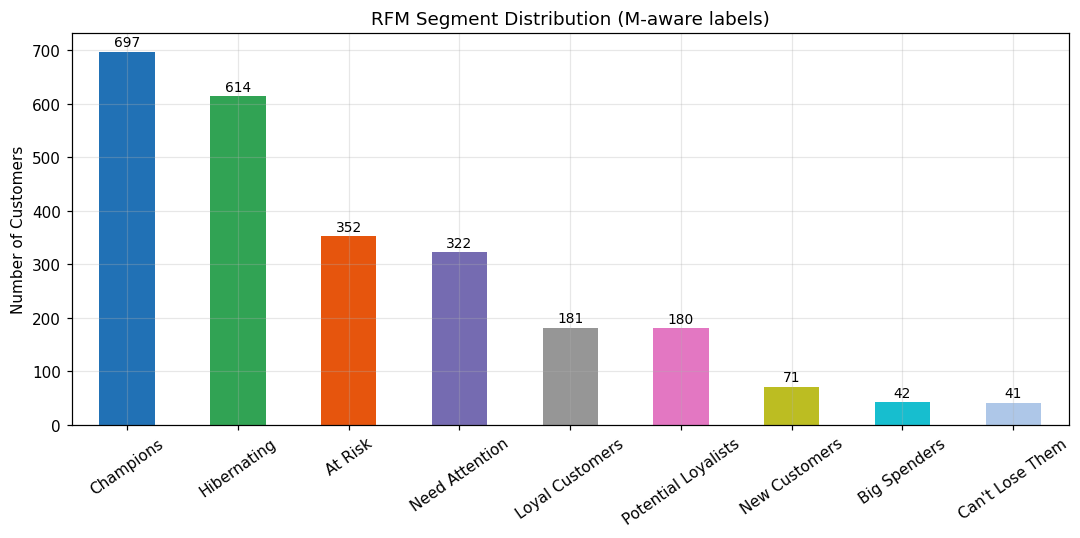

In [9]:
step("RFM segment distribution")

seg_counts = rfm["segment"].value_counts()
colors = [ACCENT_BLUE, ACCENT_GREEN, ACCENT_ORANGE, ACCENT_PURPLE,
          ACCENT_GREY, "#e377c2", "#bcbd22", "#17becf", "#aec7e8"]

fig, ax = plt.subplots(figsize=(10, 5))
seg_counts.plot(kind="bar", ax=ax, color=colors[:len(seg_counts)])
ax.set_ylabel("Number of Customers")
ax.set_xlabel("")
ax.set_title("RFM Segment Distribution (M-aware labels)")
ax.tick_params(axis="x", rotation=35)
for i, (seg, count) in enumerate(seg_counts.items()):
    ax.text(i, count + 10, str(count), ha="center", fontsize=9)
fig.tight_layout()
savefig(fig, "rfm_distribution.png")
plt.show()

## 4. K-Means on Nine Behavioral Features

**The Golden Rule: cluster on behavior, profile with demographics.**
All nine features in `BASE_COLS` are behavioral — revenue, frequency,
recency, basket size, breadth, discount sensitivity. Demographics
(`AGE_DESC`, `INCOME_DESC`, `HOUSEHOLD_SIZE_DESC`) only enter *after* the
clustering, in the profiling section.

**Log-transform the skewed features first.** Several variables (revenue,
frequency, recency, AOV, basket size) are heavily right-skewed — a handful of
customers buy enormously more than the rest. `StandardScaler` only centers and
rescales; it leaves those long tails intact. Fed raw, K-Means spends its first
splits separating big spenders from small ones and mostly *rediscovers value
tiers* (it favors K=3), and any 4th+ cluster it finds is a tiny outlier pocket
that fails the 10% floor. Applying `log1p` to the skewed variables before
scaling compresses the tails, so the clusters reflect behavioral *shape*, not
just spend magnitude — and balanced, actionable segments emerge at K=4–6.

In [10]:
step("Scale features for clustering (log-transform skewed variables)")

skew = customers[BASE_COLS].skew()
LOG_COLS = skew[skew > CONFIG["skew_threshold"]].index.tolist()

X_raw = customers[BASE_COLS].copy()
X_raw[LOG_COLS] = np.log1p(X_raw[LOG_COLS])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Base variables ({len(BASE_COLS)}): {BASE_COLS}")
print(f"Log-transformed (skew > {CONFIG['skew_threshold']}): {LOG_COLS}")
print(f"Shape: {X_scaled.shape}")
print(f"\nScaled means (should be ~0):  {X_scaled.mean(axis=0).round(3)}")
print(f"Scaled stds  (should be ~1):  {X_scaled.std(axis=0).round(3)}")


  Step 7: Scale features for clustering (log-transform skewed variables)

Base variables (9): ['total_revenue', 'frequency', 'recency_weeks', 'avg_order_value', 'basket_size', 'active_weeks', 'discount_share', 'department_breadth', 'top_department_share']
Log-transformed (skew > 1.0): ['total_revenue', 'frequency', 'recency_weeks', 'avg_order_value', 'basket_size']
Shape: (2500, 9)

Scaled means (should be ~0):  [ 0. -0.  0. -0. -0. -0. -0.  0. -0.]
Scaled stds  (should be ~1):  [1. 1. 1. 1. 1. 1. 1. 1. 1.]


We search K = 2..20 and look at the **elbow** — within-cluster inertia vs K.
We deliberately skip the silhouette score: on customer data it tends to favor
K=2 (a coarse VIP-vs-rest split) and would only muddy the choice.

The elbow narrows the range but rarely pins the number. Its sharpest bend here
is near **K=3** — but K=3 just recovers value tiers (heavy / average / lapsed),
essentially what decile and RFM already told us. The chapter's goal is to go
*beyond* value tiers, so we push into the practical 4–8 range and let
**actionability** decide: pick the K whose segments a marketer would treat
differently, then sanity-check that each is large enough to act on. The 10%
figure below is a rough guide, not a hard rule — the right minimum depends on
the business and the campaign.

In [11]:
step("K-Means: elbow search")

km_results = []
for k in CONFIG["k_range"]:
    km = KMeans(n_clusters=k, n_init=10, random_state=CONFIG["random_state"])
    km.fit(X_scaled)
    km_results.append({"k": k, "inertia": km.inertia_})
    print(f"  K={k:2d}  |  Inertia={km.inertia_:>10,.0f}")

km_df = pd.DataFrame(km_results)


  Step 8: K-Means: elbow search



  K= 2  |  Inertia=    15,650
  K= 3  |  Inertia=    13,710


  K= 4  |  Inertia=    12,531


  K= 5  |  Inertia=    11,755
  K= 6  |  Inertia=    11,090


  K= 7  |  Inertia=    10,571
  K= 8  |  Inertia=    10,151


...

  K=11  |  Inertia=     9,151
  K=12  |  Inertia=     8,860


  K=13  |  Inertia=     8,626
  K=14  |  Inertia=     8,411


  K=15  |  Inertia=     8,167
  K=16  |  Inertia=     8,006


  K=17  |  Inertia=     7,850
  K=18  |  Inertia=     7,736


  K=19  |  Inertia=     7,548
  K=20  |  Inertia=     7,437



  Step 9: Elbow plot



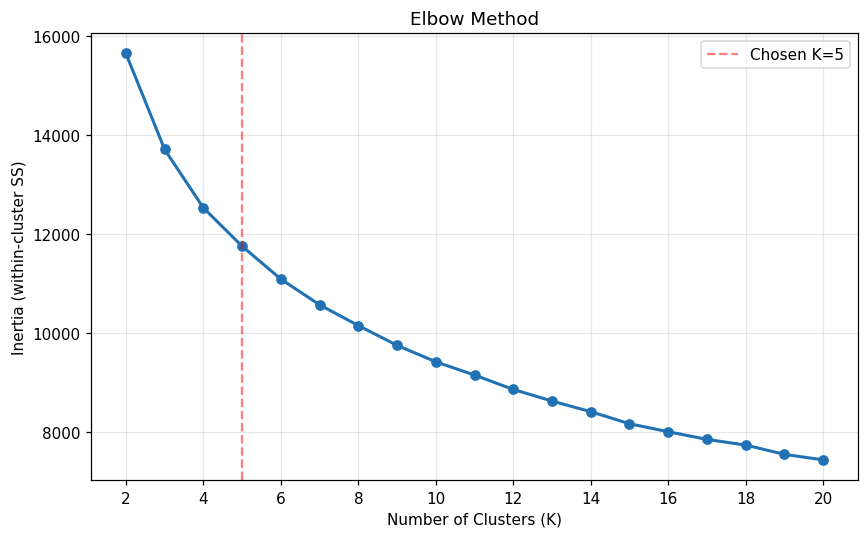

Elbow bends sharpest near K=3 (≈ value tiers); we take K=5 from the practical range by actionability, not by the elbow alone.


In [12]:
step("Elbow plot")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(km_df["k"], km_df["inertia"], "o-", color=ACCENT_BLUE, linewidth=2)
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia (within-cluster SS)")
ax.set_title("Elbow Method")
ax.set_xticks(list(range(2, 21, 2)))
ax.axvline(x=CONFIG["final_k"], color="red", linestyle="--", alpha=0.5,
           label=f"Chosen K={CONFIG['final_k']}")
ax.legend()

fig.tight_layout()
savefig(fig, "elbow.png")
plt.show()

print(f"Elbow bends sharpest near K=3 (≈ value tiers); we take K={CONFIG['final_k']} from the "
      f"practical range by actionability, not by the elbow alone.")

In [13]:
step("Fit final K-Means and validate cluster sizes")

final_k = CONFIG["final_k"]
km_final = KMeans(n_clusters=final_k, n_init=10, random_state=CONFIG["random_state"])
customers["km_segment"] = km_final.fit_predict(X_scaled)

sizes = customers["km_segment"].value_counts(normalize=True).sort_index()
print(f"Final K-Means: K={final_k}")
print(f"\nCluster shares:")
for seg, share in sizes.items():
    flag = "" if share >= CONFIG["min_cluster_share"] else "  (below the ~10% guide)"
    print(f"  Segment {seg}: {share:.1%}{flag}")
if (sizes < CONFIG["min_cluster_share"]).any():
    print("\nNote: a cluster is below the ~10% guide. That is fine if it is a "
          "deliberate niche; otherwise consider a smaller K or different features.")


  Step 10: Fit final K-Means and validate cluster sizes



Final K-Means: K=5

Cluster shares:
  Segment 0: 22.9%
  Segment 1: 24.9%
  Segment 2: 11.5%
  Segment 3: 21.6%
  Segment 4: 19.1%


### Dendrogram — visual intuition for K

Agglomerative clustering on a 500-household sample shows the merging
hierarchy. Cutting the tree at different heights yields different K. We
overlay the chosen-K cut so the dendrogram matches the K-Means choice above —
this is *visual intuition*, not an independent method.


  Step 11: Dendrogram (intuition for K=5)



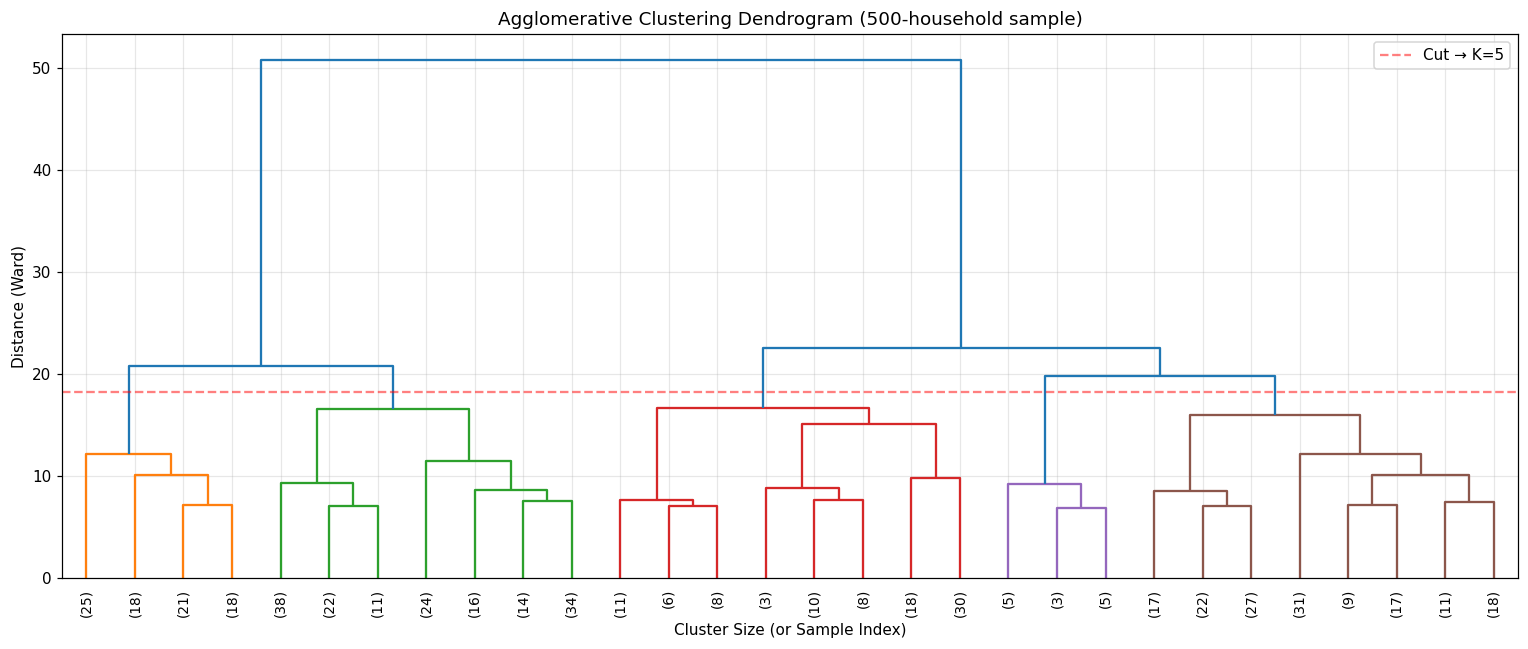

In [14]:
step(f"Dendrogram (intuition for K={CONFIG['final_k']})")

from scipy.cluster.hierarchy import linkage, dendrogram as scipy_dendrogram

np.random.seed(CONFIG["random_state"])
sample_idx = np.random.choice(len(X_scaled), size=500, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method="ward")

# A horizontal cut yielding K clusters sits between the K-th and (K-1)-th
# highest merge heights; use the midpoint so the line and colors match K.
cut_height = (Z[-final_k, 2] + Z[-(final_k - 1), 2]) / 2

fig, ax = plt.subplots(figsize=(14, 6))
scipy_dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    ax=ax,
    color_threshold=cut_height,   # color by the chosen-K cut
)
ax.set_xlabel("Cluster Size (or Sample Index)")
ax.set_ylabel("Distance (Ward)")
ax.set_title("Agglomerative Clustering Dendrogram (500-household sample)")
ax.axhline(y=cut_height, color="red", linestyle="--", alpha=0.5,
           label=f"Cut → K={final_k}")
ax.legend()
fig.tight_layout()
savefig(fig, "dendrogram.png")
plt.show()

customers.to_csv(_TABLES / "trad_cluster_assignments.csv", index=False)

## 5. Segment Profiling

Now we answer **who is in each segment?**

Step 1: Profile base variables (what they *do*) — heatmap of cluster means.
Step 2: Profile descriptor variables (who they *are*) — demographic cross-tabs.


  Step 12: Segment profile heatmap (base variables)



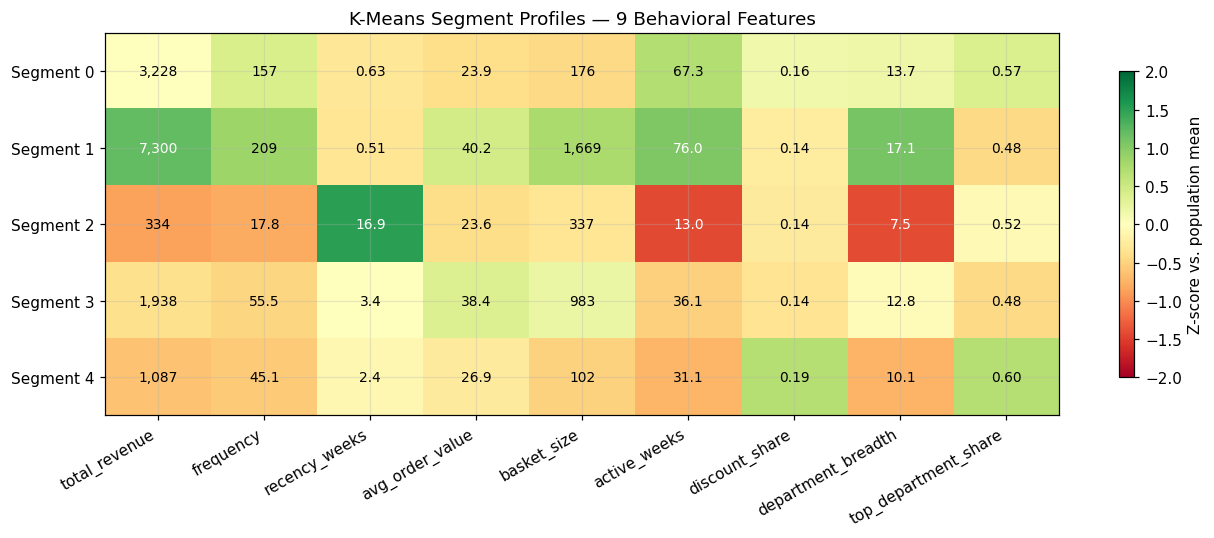

In [15]:
step("Segment profile heatmap (base variables)")

profile = customers.groupby("km_segment")[BASE_COLS].mean()

pop_mean = customers[BASE_COLS].mean()
pop_std = customers[BASE_COLS].std()
profile_z = (profile - pop_mean) / pop_std


def _fmt(val):
    """Compact value formatter that handles the mixed scales in BASE_COLS."""
    if abs(val) >= 100:
        return f"{val:,.0f}"
    if abs(val) >= 1:
        return f"{val:.1f}"
    return f"{val:.2f}"


fig, ax = plt.subplots(figsize=(12, max(3, final_k * 0.8 + 1)))
im = ax.imshow(profile_z.values, cmap="RdYlGn", aspect="auto", vmin=-2, vmax=2)

ax.set_xticks(range(len(BASE_COLS)))
ax.set_xticklabels(BASE_COLS, rotation=30, ha="right")
ax.set_yticks(range(final_k))
ax.set_yticklabels([f"Segment {i}" for i in range(final_k)])

for i in range(final_k):
    for j in range(len(BASE_COLS)):
        val = profile.iloc[i, j]
        ax.text(j, i, _fmt(val), ha="center", va="center", fontsize=9,
                color="white" if abs(profile_z.iloc[i, j]) > 1 else "black")

fig.colorbar(im, ax=ax, label="Z-score vs. population mean", shrink=0.8)
ax.set_title("K-Means Segment Profiles — 9 Behavioral Features")
fig.tight_layout()
savefig(fig, "segment_heatmap.png")
plt.show()

**Naming the segments.** We map K-Means clusters to operating-friendly
names from the heatmap above. The exact mapping depends on which cluster
came out on top of which axis when the notebook executed — adjust the
labels by reading the heatmap (highest z-scores point you at the
distinguishing feature).

In [16]:
step("Map K-Means segments to action tiers")

# Rank segments by mean revenue (post-fit) and assign tiers by rank.
# This keeps the labels stable across re-runs even if KMeans relabels.
seg_rev = (
    profile["total_revenue"]
    .sort_values(ascending=False)
    .index.tolist()
)
tier_labels = ["VIP retention", "Growth: upsell", "Low-cost nurture"]
# Pad if K > 3 (defensive)
while len(tier_labels) < final_k:
    tier_labels.append(f"Behavioral tier {len(tier_labels)+1}")

action_map_km = {seg: tier_labels[i] for i, seg in enumerate(seg_rev)}
customers["km_action_tier"] = customers["km_segment"].map(action_map_km)

print("K-Means → action tier mapping (ranked by mean revenue):")
for seg, tier in action_map_km.items():
    n = (customers["km_segment"] == seg).sum()
    print(f"  Segment {seg} (n={n:,}): {tier}")


  Step 13: Map K-Means segments to action tiers

K-Means → action tier mapping (ranked by mean revenue):
  Segment 1 (n=623): VIP retention
  Segment 0 (n=573): Growth: upsell
  Segment 3 (n=539): Low-cost nurture
  Segment 4 (n=478): Behavioral tier 4
  Segment 2 (n=287): Behavioral tier 5


In [17]:
step("Descriptor variable cross-tabs (demographics)")

cust_demo = customers.merge(demographics, on="household_key", how="inner")
print(f"Households with demographics: {len(cust_demo):,} / {len(customers):,}")


  Step 14: Descriptor variable cross-tabs (demographics)

Households with demographics: 801 / 2,500


> **Note:** Only ~32% of households have demographics; the profiling tables
> below cover this subset only. The K-Means assignments themselves use the
> behavioral features available for all 2,500 households.

In [18]:
desc_cols = ["AGE_DESC", "INCOME_DESC", "HOUSEHOLD_SIZE_DESC"]

for col in desc_cols:
    ct = pd.crosstab(cust_demo["km_segment"], cust_demo[col], normalize="index")
    print(f"\n{'─'*60}")
    print(f"  {col} (row % within each segment)")
    print(f"{'─'*60}")
    display(ct.round(3))


────────────────────────────────────────────────────────────
  AGE_DESC (row % within each segment)
────────────────────────────────────────────────────────────


AGE_DESC,19-24,25-34,35-44,45-54,55-64,65+
km_segment,,,,,,
0,0.08,0.17,0.17,0.36,0.10,0.12
1,0.05,0.18,0.28,0.36,0.07,0.06
2,0.00,0.00,0.00,0.00,0.00,1.00
3,0.06,0.15,0.26,0.34,0.04,0.14
4,0.00,0.30,0.25,0.45,0.00,0.00



────────────────────────────────────────────────────────────
  INCOME_DESC (row % within each segment)
────────────────────────────────────────────────────────────


INCOME_DESC,100-124K,125-149K,15-24K,150-174K,175-199K,200-249K,25-34K,250K+,35-49K,50-74K,75-99K,Under 15K
km_segment,,,,,,,,,,,,
0,0.03,0.02,0.15,0.02,0.01,0.00,0.11,0.00,0.25,0.20,0.10,0.11
1,0.06,0.06,0.06,0.05,0.02,0.01,0.09,0.02,0.18,0.26,0.12,0.07
2,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
3,0.04,0.07,0.09,0.04,0.00,0.00,0.07,0.01,0.24,0.25,0.15,0.03
4,0.00,0.00,0.10,0.00,0.00,0.00,0.20,0.00,0.20,0.25,0.20,0.05



────────────────────────────────────────────────────────────
  HOUSEHOLD_SIZE_DESC (row % within each segment)
────────────────────────────────────────────────────────────


HOUSEHOLD_SIZE_DESC,1,2,3,4,5+
km_segment,,,,,
0,0.36,0.37,0.13,0.06,0.08
1,0.30,0.41,0.13,0.08,0.09
2,1.00,0.00,0.00,0.00,0.00
3,0.28,0.47,0.19,0.02,0.04
4,0.40,0.25,0.10,0.10,0.15


## 6. Decile Migration Matrix — Temporal Stability

A segmentation is only useful if it persists over time. We split the 102
weeks into two halves, build revenue-based quintile-pairs independently
in each half, and check the migration matrix. Strong diagonals mean the
value tiers are stable; heavy off-diagonal mass means customers shuffle
unpredictably.


  Step 15: Decile migration matrix



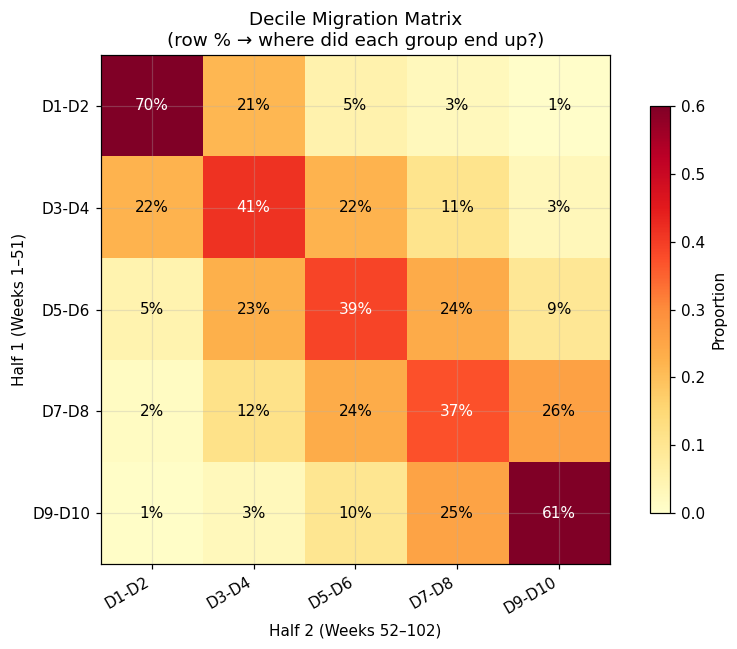

Customers in both halves: 2,476
Diagonal retention rates:
  D1-D2: 70%
  D3-D4: 41%
  D5-D6: 39%
  D7-D8: 37%
  D9-D10: 61%


In [19]:
step("Decile migration matrix")

mid_week = CONFIG["max_week"] // 2  # week 51

txn_h1 = txn[txn["WEEK_NO"] <= mid_week]
txn_h2 = txn[txn["WEEK_NO"] > mid_week]

rev_h1 = txn_h1.groupby("household_key")["SALES_VALUE"].sum()
rev_h2 = txn_h2.groupby("household_key")["SALES_VALUE"].sum()

common = rev_h1.index.intersection(rev_h2.index)
rev_h1 = rev_h1.loc[common]
rev_h2 = rev_h2.loc[common]

dec_h1 = pd.qcut(rev_h1.rank(method="first", ascending=False), q=5,
                 labels=["D1-D2", "D3-D4", "D5-D6", "D7-D8", "D9-D10"])
dec_h2 = pd.qcut(rev_h2.rank(method="first", ascending=False), q=5,
                 labels=["D1-D2", "D3-D4", "D5-D6", "D7-D8", "D9-D10"])

migration = pd.crosstab(dec_h1, dec_h2, normalize="index")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(migration.values, cmap="YlOrRd", vmin=0, vmax=0.6)

labels = migration.index.tolist()
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel("Half 2 (Weeks 52–102)")
ax.set_ylabel("Half 1 (Weeks 1–51)")
ax.set_title("Decile Migration Matrix\n(row % → where did each group end up?)")

for i in range(len(labels)):
    for j in range(len(labels)):
        val = migration.iloc[i, j]
        ax.text(j, i, f"{val:.0%}", ha="center", va="center",
                fontsize=10, color="white" if val > 0.3 else "black")

fig.colorbar(im, ax=ax, label="Proportion", shrink=0.8)
fig.tight_layout()
savefig(fig, "migration_matrix.png")
plt.show()

print(f"Customers in both halves: {len(common):,}")
print(f"Diagonal retention rates:")
for i, lbl in enumerate(labels):
    print(f"  {lbl}: {migration.iloc[i, i]:.0%}")

## 7. CRM-Ready Export

Segments only matter if they reach the activation systems. We persist a
single table joining the two complementary lenses we built — decile tier
(value) and K-Means segment (behavior) — so it can be loaded into the
CRM/ad platforms.

In [20]:
step("Export segment assignments")

crm_export = customers[[
    "household_key", "decile", "decile_action_tier",
    "km_segment", "km_action_tier",
]].copy()
crm_export = crm_export.sort_values("household_key")

display(crm_export.head(10))

# Repo-canonical path for cross-section data passed to sec4.2 (CLV chapter).
# Resolved by msbook so this works from any cwd or notebook subdirectory.
from msbook.paths import chapter_generated

_seg_out = chapter_generated(part="4", chapter="sec4.1-segmentation") / "segment_assignments.csv"
crm_export.to_csv(_seg_out, index=False)
print(f"\nWrote {len(crm_export):,} rows to {_seg_out.relative_to(_seg_out.parents[3])}")


  Step 16: Export segment assignments



,household_key,decile,decile_action_tier,km_segment,km_action_tier
0,1,D3,Grow basket or category,0,Growth: upsell
1,2,D6,Low-cost nurture,3,Low-cost nurture
2,3,D5,Low-cost nurture,4,Behavioral tier 4
3,4,D7,Low-cost nurture,2,Behavioral tier 5
4,5,D8,Suppress expensive offers,4,Behavioral tier 4
5,6,D2,Grow basket or category,1,VIP retention
6,7,D4,Grow basket or category,3,Low-cost nurture
7,8,D2,Grow basket or category,1,VIP retention
8,9,D8,Suppress expensive offers,4,Behavioral tier 4
9,10,D10,Suppress expensive offers,2,Behavioral tier 5



Wrote 2,500 rows to generated/part4/sec4.1-segmentation/segment_assignments.csv


## Key Takeaways

1. **Decile analysis** reveals the Pareto pattern: a small fraction of
   customers drive a disproportionate share of revenue.
2. **RFM with M-aware labels** stays interpretable while keeping the
   "Champions" label honest — high-value labels gate on monetary, not
   just recency and frequency.
3. **Cluster on behavior, profile with demographics.** All nine features
   fed into K-Means are behavioral; demographics enter only afterwards.
4. **K is part statistics, part judgment.** The elbow method points at
   a region; the 10% floor and "can marketing describe a different action
   for each?" decide the number.
5. **Migration analysis tests temporal stability** — segments that
   shuffle unpredictably between periods are not actionable.
6. **Operationalize or die.** Ship a `segment_assignments.csv` (or
   equivalent table) into the CRM and ad platforms; a segmentation that
   never reaches activation is a slide deck, not an operating artifact.